# Week 7 - Temporal models

Hello again. Welcome to week 7! In this week, we will focus on how to model time-dependent response (or target) variables (continuous or discrete!) in STAN/Pyro.

## Part 1: Linear dynamical system - Ancestral sampling

The usual imports...


In [88]:
import numpy as np
from matplotlib import pyplot as plt

# fix random generator seed (for reproducibility of results)
# np.random.seed(42)

# matplotlib options
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

In this part, we will use ancestral sampling to sample observations from a simple linear dynamical system:

\begin{align}
\beta &\sim \mathcal{N}(0, 0.1)\\
z*t &\sim \mathcal{N}(\beta \, z*{t-1}, \tau^2)\\
y_t &\sim \mathcal{N}(z_t, \sigma^2)
\end{align}

Again, the purpose of these is for you to get familiar with the modelling assumption in such a model and to make sure that you understand them. Furthermore, in most cases, a great thing to do for debugging your Pyro/STAN implementation of a model is to use ancestral sampling to generate some data from the model, and then try to recover the latent variables in using Pyro/STAN.

In this particular case, we would a) sample beta and some y's using ancestral sampling, and then try to b) use Pyro/STAN to recover beta from the observations y (inference). We recommend you to do b) as your **home work**, since the remaining notebooks today involve only real data, ok?


Ok, lets do the ancestral sampling for a time-series of length $T=20$ using the simple model described above.

We assume the values of tau and sigma to be given.

Notice that we also need to assign a prior to the first latent state $z_0$, e.g. $z_0 \sim \mathcal{N}(0,1)$. Why is that?


In [89]:
# assume sigma and tau to be fixed
tau = 0.1
print("tau:", tau)
sigma = 0.05
print("sigma:", sigma)

# length of the time-series
T = 20

z = np.zeros(T)  # vector to store sampled latent states
y = np.zeros(T)  # vector to store sampled observations

# sample coefficient (beta)
beta = np.random.normal(0, 1)
print("beta:", beta)

# sample latent states (z)
z[0] = np.random.normal(0, 1)  # first state is sampled separately
for t in range(1, T):
    z[t] = np.random.normal(beta * z[t - 1], tau)
print("z:", z)

# sample observations (y)
for t in range(T):
    y[t] = np.random.normal(z[t], sigma)
print("y:", y)

tau: 0.1
sigma: 0.05
beta: 0.6478676824250228
z: [-0.58396129 -0.43904462 -0.23843824 -0.1624765  -0.12123737 -0.10465957
 -0.03854172  0.07115301 -0.00763257 -0.02020864  0.03360497 -0.2243465
 -0.06503182  0.06828512  0.07305495  0.09871103  0.1817796   0.14203315
  0.22510045  0.22206799]
y: [-0.47628041 -0.41837506 -0.19712246 -0.15178712 -0.06116634 -0.12860369
 -0.0033556   0.00880681 -0.02229992 -0.03533    -0.07115978 -0.20099913
 -0.00358493 -0.01615484  0.11983827  0.10292285  0.14738492  0.1844129
  0.30941149  0.19048091]


Lets visualize the data that you've just generated:


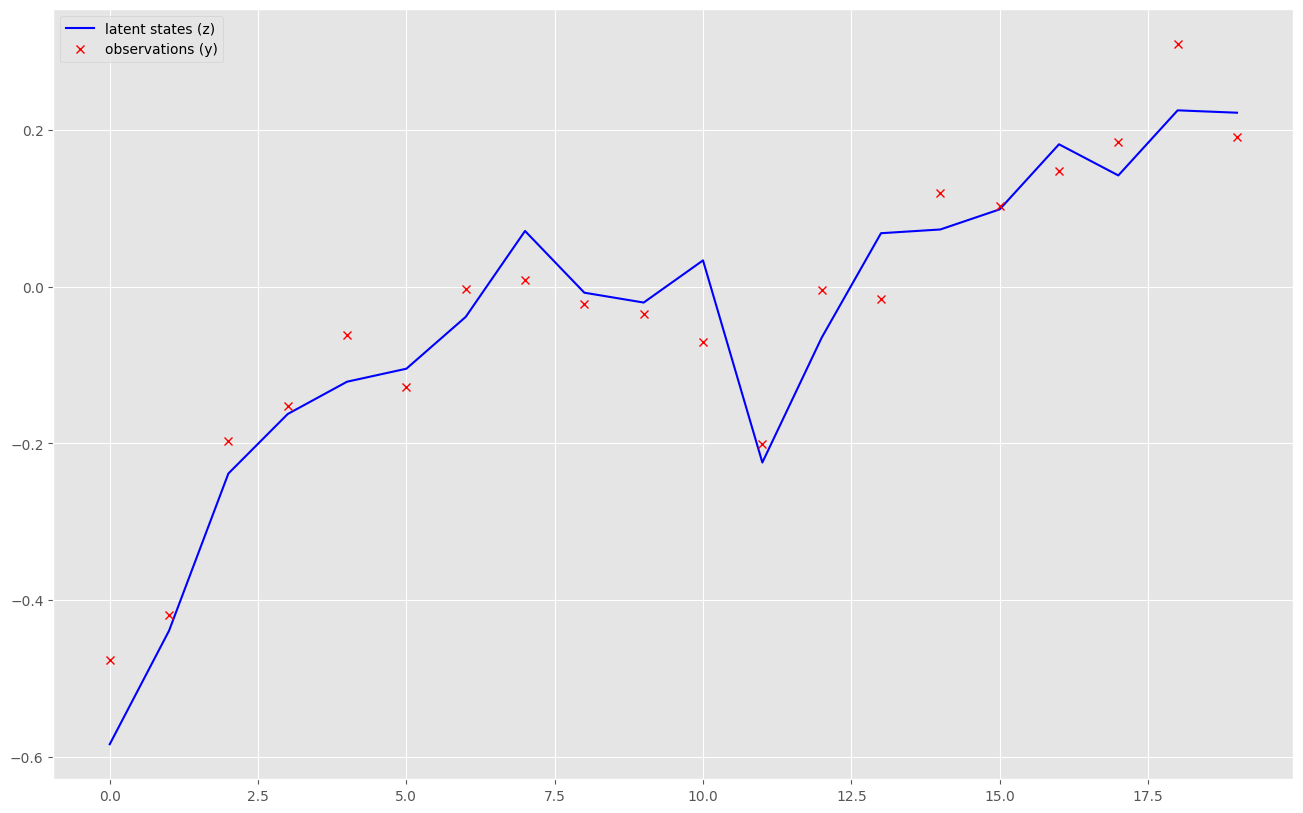

In [90]:
plt.plot(range(T), z, "b-")
plt.plot(range(T), y, "rx")
plt.legend(["latent states (z)", "observations (y)"])
plt.show()

Run the ancestral sampling code several times and look at the different results that you get. Also, make sure to play with the priors.
